---
# Análisis de Sentimiento Financiero
## Python + Transformers (Hugging Face)

---

El **análisis de sentimiento** es una técnica fundamental del procesamiento de lenguaje natural (NLP) que permite identificar, extraer y clasificar automáticamente las opiniones o emociones expresadas en textos, determinando si el tono general es **positivo**, **negativo** o **neutral**.

**¿Cómo funciona?**
- Utiliza desde diccionarios léxicos predefinidos (listas de palabras asociadas a sentimientos) hasta modelos de machine learning y deep learning.
- Puede implementarse para textos en distintos idiomas, usando corpus o diccionarios específicos para cada contexto (por ejemplo, críticas de películas, análisis financiero, redes sociales).
- En contextos avanzados, se entrena un modelo de clasificación sobre corpus etiquetados.

**Aplicaciones principales:**
- Clasificación automática de reseñas (productos, películas, servicios).
- Análisis de reputación de marcas y empresas en redes sociales.
- Evaluación de sentimiento financiero (ejemplo: identificar tono "positivo" o "negativo" en noticias económicas).
- Monitoreo de la opinión pública sobre temas políticos o sociales.

En este notebook nos enfocaremos específicamente en el **análisis de sentimiento financiero**: comparar varios modelos de lenguaje (LLM) especializados en textos económicos, en inglés y en español, sobre el mismo conjunto de datos etiquetado.

### 🎯 Objetivos de aprendizaje

- Comparar, a nivel conceptual, las ventajas y desventajas del NLP tradicional frente a los LLM para tareas de análisis de sentimiento.
- Preparar un conjunto de datos financiero etiquetado (**FinancialPhraseBank**) para evaluar modelos de sentimiento.
- Cargar y aplicar varios modelos de lenguaje pre-entrenados especializados en finanzas (FinRoberta, FinBERT, DistilRoBERTa, DeBERTa y un modelo en español) usando `transformers` de Hugging Face.
- Evaluar y comparar el desempeño de los modelos con el **F1-score macro** y **matrices de confusión**.

---
---
## ⚖️ I. NLP Tradicional vs. Modelos LLM: Ventajas y Desventajas

A continuación, se comparan los enfoques tradicionales de NLP (basados en reglas, estadística y modelos clásicos) con los LLM (Large Language Models, como GPT o BERT):

|                        | **NLP Tradicional**                                                                 | **LLM (Large Language Models)**                                                 |
|------------------------|-------------------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| **Ventajas**           | - Más simple y rápido de entrenar<br>- Requiere menos recursos computacionales<br>- Fácil de interpretar y ajustar<br>- Bueno para tareas específicas o lenguajes poco representados<br>- Fácil de adaptar a corpus pequeños o altamente especializados | - Capacidad de entender contexto y ambigüedad<br>- Maneja grandes volúmenes de texto y vocabulario<br>- Resultados sobresalientes en tareas complejas (resúmenes, generación, QA, etc.)<br>- Aprende relaciones profundas entre palabras, frases y temas<br>- Se adapta a múltiples tareas sin rediseño manual |
| **Desventajas**        | - Menor capacidad para captar contexto complejo<br>- Limitado ante ironías, ambigüedades o sutilezas<br>- Depende de reglas y listas que requieren mucho trabajo manual<br>- Menor escalabilidad y generalización en tareas nuevas | - Requiere grandes recursos computacionales para entrenamiento y uso<br>- Difícil de interpretar y ajustar (“caja negra”)<br>- Puede replicar sesgos de los datos de entrenamiento<br>- Menor control sobre el proceso de toma de decisiones y resultados             |

### ¿Cuándo usar cada uno?
- **NLP tradicional**: ideal para tareas estructuradas, corpus pequeños, problemas bien definidos o cuando se requiere interpretación clara.
- **LLM**: mejor para procesamiento avanzado de lenguaje, textos extensos, tareas complejas y aplicaciones donde la comprensión contextual es clave.

> En la práctica, muchos flujos de trabajo combinan ambas estrategias según los recursos, objetivos y datos disponibles.

---

---
---
## 🛠️ II. Preparando el Entorno

### Contexto: Análisis de Sentimiento con Transformers

La celda de código presentada prepara el entorno para realizar **análisis de sentimiento** usando modelos de última generación basados en *transformers* (redes neuronales profundas especializadas en procesamiento de texto).

#### ¿Qué hace cada línea?

- `import pandas as pd`: Importa la biblioteca **pandas**, fundamental para manipulación y análisis de datos en Python.
- `from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline`: Importa funciones clave del paquete **transformers** de Hugging Face, que permiten cargar modelos preentrenados y crear pipelines de inferencia para tareas de NLP, como clasificación de sentimientos.
- `import matplotlib.pyplot as plt`: Importa la biblioteca **matplotlib** para graficar resultados (por ejemplo, la distribución de sentimientos).
- `import numpy as np`: Importa **numpy** para operaciones matemáticas y manejo eficiente de arrays.
- `from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report`: Importa funciones de **scikit-learn** para evaluar la calidad de las predicciones del modelo (precisión, recall, F1, etc.).

#### ¿Para qué se utiliza este setup?

Este entorno permite:
- **Cargar un modelo de análisis de sentimiento** ya entrenado (como BERT, RoBERTa, DistilBERT, etc.) desde la biblioteca Hugging Face.
- **Tokenizar y preprocesar textos** para convertirlos al formato requerido por el modelo.
- **Clasificar textos** automáticamente según su sentimiento (positivo, negativo, neutral).
- **Evaluar el rendimiento** del modelo utilizando métricas estándar si se cuenta con datos etiquetados.
- **Visualizar los resultados** con gráficos.

---

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*encoder_attention_mask.*", category=FutureWarning)

import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

/Users/fernandodiaz/dev-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
---
## 📂 III. Preparación de los Datos

Para realizar análisis de sentimiento con modelos modernos, es esencial contar con un **conjunto de datos etiquetado**. En este caso, usamos el archivo `Sentences_AllAgree.txt` del **FinancialPhraseBank** (Malo et al., 2014): frases en inglés extraídas de noticias financieras, cada una asociada a una etiqueta de sentimiento (`positive`, `negative` o `neutral`), separadas por el símbolo `@`. Este subconjunto (*AllAgree*) incluye únicamente las 2.264 frases en las que **el 100% de los anotadores humanos coincidió** en la etiqueta, lo que lo convierte en un estándar de referencia confiable.

> 📌 **Licencia:** el FinancialPhraseBank se distribuye bajo licencia **CC BY-NC-SA 3.0** (uso no comercial, con atribución) — [Malo, P., Sinha, A., Korhonen, P., Wallenius, J., & Takala, P. (2014). *Good debt or bad debt: Detecting semantic orientations in economic texts*. Journal of the Association for Information Science and Technology, 65.](https://huggingface.co/datasets/takala/financial_phrasebank)

**Proceso de preparación:**

- Se lee el archivo línea por línea, separando cada frase y su etiqueta.
- Se crea un *DataFrame* con dos columnas:
    - `original_text_en` (el texto original en inglés)
    - `labeled_sentiment` (la etiqueta manual: `positive`, `negative` o `neutral`)
- Se eliminan espacios y caracteres residuales de las etiquetas para asegurar limpieza.

> El resultado es una tabla estructurada con textos y sus sentimientos verdaderos, lista para utilizarse en el entrenamiento, validación o prueba de modelos de análisis de sentimiento, tanto con enfoques clásicos de NLP como con modelos de lenguaje basados en *transformers*.

**Este dataset es un punto de partida ideal para comparar la efectividad de distintos enfoques de análisis de sentimiento, desde métodos tradicionales hasta modelos de última generación como BERT.**

---

In [2]:
from IPython.display import HTML

# Muestra la tabla completa (sin truncar filas) dentro de una ventana de
# altura fija -- funciona igual en VS Code y en el sitio web, ya que el
# scroll viene de un estilo inline, no de una hoja de estilos externa.
# La altura por defecto (500px) deja ver ~20 filas antes de necesitar scroll.
def show_table(df, height="500px"):
    tabla_html = df.to_html()
    return HTML(
        f'<div style="max-height:{height}; overflow:auto; border:1px solid #ddd; padding:4px;">'
        f'{tabla_html}</div>'
    )

In [3]:
source_file = "Sentences_AllAgree.txt"

# Open and read the text file with appropriate encoding
with open(source_file, 'r', encoding='latin-1') as file:
    data = file.read().split('\n')

# Split each row into two columns based on the '@' separator
split_data = [row.rsplit('@', 1) for row in data if row and '@' in row]

# Create a DataFrame
df = pd.DataFrame(split_data, columns=['text', 'labeled_sentiment'])

# Rename and clean
df = df.rename(columns={'text': 'original_text_en'})
df['labeled_sentiment'] = df['labeled_sentiment'].str.replace('@', '', regex=False)
df['labeled_sentiment'] = df['labeled_sentiment'].str.replace(" ", "", regex=False)

# Display the DataFrame
show_table(df)

,original_text_en,labeled_sentiment
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",neutral
1,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .",positive
2,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .",positive
3,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .,positive
4,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .",positive
5,"Finnish Talentum reports its operating profit increased to EUR 20.5 mn in 2005 from EUR 9.3 mn in 2004 , and net sales totaled EUR 103.3 mn , up from EUR 96.4 mn .",positive
6,"Clothing retail chain Sepp+ñl+ñ 's sales increased by 8 % to EUR 155.2 mn , and operating profit rose to EUR 31.1 mn from EUR 17.1 mn in 2004 .",positive
7,"Consolidated net sales increased 16 % to reach EUR74 .8 m , while operating profit amounted to EUR0 .9 m compared to a loss of EUR0 .7 m in the prior year period .",positive
8,"Foundries division reports its sales increased by 9.7 % to EUR 63.1 mn from EUR 57.5 mn in the corresponding period in 2006 , and sales of the Machine Shop division increased by 16.4 % to EUR 41.2 mn from EUR 35.4 mn in the corresponding period in 2006 .",positive
9,"HELSINKI ( AFX ) - Shares closed higher , led by Nokia after it announced plans to team up with Sanyo to manufacture 3G handsets , and by Nokian Tyres after its fourth-quarter earnings report beat analysts ' expectations , dealers said .",positive


---
---
## 🤖 IV. Selección y Carga de Modelos de Sentimiento Financiero

En esta sección, se preparan diferentes modelos de lenguaje pre-entrenados especializados en **análisis de sentimiento financiero**, utilizando la librería `transformers` de Hugging Face. El objetivo es comparar la capacidad de distintos modelos de última generación para clasificar el sentimiento de textos económicos y financieros.

**¿Qué modelos se cargan?**

- **Financial RoBERTa Large Sentiment:** modelo basado en RoBERTa, ajustado específicamente para el análisis de sentimiento en textos financieros en inglés.
- **FinBERT:** variante de BERT entrenada sobre textos financieros, ampliamente utilizada para tareas de análisis de sentimiento en finanzas.
- **DistilRoBERTa-finetuned-financial-news:** modelo DistilRoBERTa afinado para clasificar el sentimiento de noticias financieras en inglés, ofreciendo buena velocidad y rendimiento.
- **DeBERTa-v3-small-ft-financial-news:** modelo DeBERTa adaptado para análisis de sentimiento en noticias económicas.
- **Finance Sentiment Español:** modelo BERT entrenado para clasificar sentimiento en textos financieros en español, permitiendo aplicar análisis multilingüe.

Cada modelo se carga con su respectivo *tokenizer* y se integra en un *pipeline* de clasificación de texto, lo que permite analizar automáticamente el sentimiento de frases o textos completos.

> Estos modelos LLM permiten llevar el análisis de sentimiento más allá de los enfoques tradicionales, aplicando inteligencia artificial de última generación para comprender mejor el tono de los textos financieros y económicos.

### ¿El largo de los párrafos afecta el rendimiento?

En el archivo de ejemplo, cada fila corresponde a una **frase corta o párrafo breve** (normalmente de 1 a 3 oraciones, entre 10 y 40 palabras) — más parecido a un titular de noticias que a un párrafo extenso. Esto es relevante porque los modelos LLM como BERT, RoBERTa y sus variantes financieras están **optimizados para procesar textos de longitud limitada** (generalmente entre 1 y 4 oraciones por predicción). Si el texto es muy largo:

- **Se recorta**: muchos modelos cortan el texto si supera el máximo permitido (por ejemplo, 512 tokens).
- **Se pierde contexto**: los textos extensos pueden quedar truncados, afectando la calidad de la predicción, especialmente si la información relevante está al final del párrafo.
- **La predicción es menos precisa**: los modelos funcionan mejor con frases o párrafos cortos y centrados en una sola idea o sentimiento.

> 📌 También es posible construir un **Document Feature Matrix (DFM)** a partir de estos mismos textos si se desea aplicar técnicas clásicas de NLP (frecuencia de palabras, n-gramas, modelado de tópicos) — en R con `quanteda` o en Python con `scikit-learn`, tratando cada frase como un "documento".

---

In [4]:
#Model Selection and Loading

# Financial Roberta Model (https://huggingface.co/soleimanian/financial-roberta-large-sentiment)
model_name_FinRoberta = "soleimanian/financial-roberta-large-sentiment"
tokenizer_FinRoberta = AutoTokenizer.from_pretrained(model_name_FinRoberta)
model_FinRoberta = AutoModelForSequenceClassification.from_pretrained(model_name_FinRoberta)
classifier_FinRoberta = pipeline('text-classification', model=model_FinRoberta, tokenizer=tokenizer_FinRoberta, device=0)

# FinBert model (https://huggingface.co/ProsusAI/finbert)
model_name_FinBert = "ProsusAI/finbert"
tokenizer_FinBert = AutoTokenizer.from_pretrained(model_name_FinBert)
model_FinBert = AutoModelForSequenceClassification.from_pretrained(model_name_FinBert)
classifier_FinBert = pipeline('text-classification', model=model_FinBert, tokenizer=tokenizer_FinBert, device=0)

# DistilRoberta-financial-sentiment (https://huggingface.co/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis)
model_name_DistilRoberta = "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis"
tokenizer_DistilRoberta = AutoTokenizer.from_pretrained(model_name_DistilRoberta)
model_DistilRoberta = AutoModelForSequenceClassification.from_pretrained(model_name_DistilRoberta)
classifier_DistilRoberta = pipeline('text-classification', model=model_DistilRoberta, tokenizer=tokenizer_DistilRoberta, device=0)

# DeBERTa-v3-small-ft-news-sentiment-analisys (https://huggingface.co/mrm8488/deberta-v3-ft-financial-news-sentiment-analysis)
model_name_DeBerta = "mrm8488/deberta-v3-ft-financial-news-sentiment-analysis"
tokenizer_DeBerta = AutoTokenizer.from_pretrained(model_name_DeBerta)
model_DeBerta = AutoModelForSequenceClassification.from_pretrained(model_name_DeBerta)
classifier_DeBerta = pipeline('text-classification', model=model_DeBerta, tokenizer=tokenizer_DeBerta, device=0)

#Finance Sentiment Español (https://huggingface.co/bardsai/finance-sentiment-es-base?library=true)
#paper: https://www.researchgate.net/publication/358284785_FinancialBERT_-_A_Pretrained_Language_Model_for_Financial_Text_Mining
model_name_FinESpañol = "bardsai/finance-sentiment-es-base"
tokenizer_FinEspañol = AutoTokenizer.from_pretrained(model_name_FinESpañol)
model_FinEspañol = AutoModelForSequenceClassification.from_pretrained(model_name_FinESpañol)
classifier_FinEspañol = pipeline('text-classification', model=model_FinEspañol, tokenizer=tokenizer_FinEspañol, device=0)

Device set to use mps:0
Device set to use mps:0
Device set to use mps:0
Device set to use mps:0
Device set to use mps:0


---
---
## ⚙️ V. Generando Predicciones con Múltiples Modelos

### Función `Make_Predictions`: Evaluación Comparativa de Modelos de Sentimiento

La función `Make_Predictions` permite aplicar de manera sistemática varios modelos de análisis de sentimiento a un conjunto de textos. Su propósito principal es facilitar la comparación entre modelos LLM específicos del dominio financiero y obtener las predicciones correspondientes para cada modelo sobre los mismos datos.

**¿Qué hace la función?**

- Toma como entrada una columna de textos de un DataFrame y aplica múltiples clasificadores de sentimiento: FinRoberta, FinBert, DistilRoberta, DeBERTa y FinEspañol.
- Cada modelo procesa el mismo texto y genera una etiqueta de sentimiento (por ejemplo, positivo, negativo, neutral), que se transforma a formato numérico usando un diccionario de mapeo.
- Las predicciones de todos los modelos se almacenan en un nuevo DataFrame, permitiendo comparar los resultados de cada modelo sobre cada texto de manera directa.
- Este enfoque es útil para seleccionar el modelo que mejor se ajusta al dominio de interés, analizar discrepancias entre modelos y evaluar la robustez de las predicciones automáticas frente a etiquetas humanas.

**Ventajas:**
- Permite aplicar distintos modelos preentrenados de forma eficiente y paralela.
- Facilita la evaluación objetiva del rendimiento de los modelos en tareas de sentimiento específicas (por ejemplo, textos financieros en inglés y español).
- El resultado puede ser utilizado para calcular métricas de desempeño (accuracy, F1, precision, recall) y realizar análisis de errores.

---

In [5]:
def Make_Predictions(col_name, dataframe, lang, mapping):

    texts = dataframe[col_name].to_list()

    print(f"Making FinRoberta {(col_name)} predictions...")
    results_LLM_FinRoberta = classifier_FinRoberta(texts, batch_size=1)
    df_results_LLM_FinRoberta = pd.DataFrame(results_LLM_FinRoberta, columns=["label"])
    df_results_LLM_FinRoberta['label'] = df_results_LLM_FinRoberta['label'].map(mapping)
    df_results_LLM_FinRoberta = df_results_LLM_FinRoberta.rename(columns={'label': f"LLM FinRoberta {col_name} sentiment"})

    print(f"Making FinBert {col_name} predictions...")
    results_LLM_FinBert = classifier_FinBert(texts, batch_size=1)
    df_results_LLM_FinBert = pd.DataFrame(results_LLM_FinBert, columns=["label"])
    df_results_LLM_FinBert['label'] = df_results_LLM_FinBert['label'].map(mapping)
    df_results_LLM_FinBert = df_results_LLM_FinBert.rename(columns={'label': f"LLM FinBert {col_name} sentiment"})

    print(f"Making DistilRoberta {col_name} predictions...")
    results_LLM_DistilRoberta = classifier_DistilRoberta(texts, batch_size=1)
    df_results_LLM_DistilRoberta = pd.DataFrame(results_LLM_DistilRoberta, columns=["label"])
    df_results_LLM_DistilRoberta['label'] = df_results_LLM_DistilRoberta['label'].map(mapping)
    df_results_LLM_DistilRoberta = df_results_LLM_DistilRoberta.rename(columns={'label': f"LLM DistilRoberta {col_name} sentiment"})

    print(f"Making DeBerta {col_name} predictions...")
    results_LLM_DeBerta = classifier_DeBerta(texts, batch_size=1)
    df_results_LLM_DeBerta = pd.DataFrame(results_LLM_DeBerta, columns=["label"])
    df_results_LLM_DeBerta['label'] = df_results_LLM_DeBerta['label'].map(mapping)
    df_results_LLM_DeBerta = df_results_LLM_DeBerta.rename(columns={'label': f"LLM DeBerta {col_name} sentiment"})

    print(f"Making FinEspañol {col_name} predictions...")
    results_LLM_FinEspañol = classifier_FinEspañol(texts, batch_size=1)
    df_results_LLM_FinEspañol = pd.DataFrame(results_LLM_FinEspañol, columns=["label"])
    df_results_LLM_FinEspañol['label'] = df_results_LLM_FinEspañol['label'].map(mapping)
    df_results_LLM_FinEspañol = df_results_LLM_FinEspañol.rename(columns={'label': f"LLM FinEspañol {col_name} sentiment"})

    df_results_LLM = pd.concat([df_results_LLM_FinRoberta, df_results_LLM_FinBert, df_results_LLM_DistilRoberta, df_results_LLM_DeBerta, df_results_LLM_FinEspañol], axis=1)

    return df_results_LLM

### Mapeo de Sentimientos: De Texto a Valores Numéricos

En el análisis de sentimiento, es común que las etiquetas ("neutral", "positive", "negative") se conviertan a valores numéricos para facilitar el procesamiento y la evaluación con modelos de machine learning.

En este caso, se define un diccionario `sentiment_mapping` para traducir las etiquetas textuales a valores numéricos estándar:
- **neutral** → `0`
- **positive** → `1`
- **negative** → `-1`

Luego, se aplica esta conversión a la columna `labeled_sentiment` del DataFrame, reemplazando cada etiqueta textual por su valor numérico correspondiente. Esto permite comparar fácilmente las predicciones de los modelos con las etiquetas reales, y calcular métricas de desempeño como **accuracy**, **precision**, **recall** y **f1-score**.

> **Resumen:** este paso convierte las etiquetas de sentimiento en un formato amigable para algoritmos de evaluación y análisis cuantitativo.

In [6]:
sentiment_mapping = {'neutral': 0, 'positive': 1, 'negative': -1}

df['labeled_sentiment'] = df['labeled_sentiment'].map(sentiment_mapping)

df.head()

,original_text_en,labeled_sentiment
0,"According to Gran , the company has no plans t...",0
1,"For the last quarter of 2010 , Componenta 's n...",1
2,"In the third quarter of 2010 , net sales incre...",1
3,Operating profit rose to EUR 13.1 mn from EUR ...,1
4,"Operating profit totalled EUR 21.1 mn , up fro...",1


La siguiente celda aplica la función `Make_Predictions` a la columna de textos en inglés (`original_text_en`) de la base de datos. Esta función genera, para cada frase, la predicción de sentimiento utilizando cinco modelos de lenguaje preentrenados en finanzas: FinRoberta, FinBert, DistilRoberta, DeBERTa y FinEspañol. El resultado es un nuevo DataFrame que contiene las etiquetas de sentimiento (positivo, negativo o neutral) asignadas por cada modelo para cada oración. Esto permite comparar el desempeño relativo de los distintos modelos sobre el mismo conjunto de textos, facilitando la evaluación y el análisis del sentimiento financiero con distintos enfoques de inteligencia artificial.

In [7]:
df_original_EN = Make_Predictions("original_text_en", df, "en", sentiment_mapping)

Making FinRoberta original_text_en predictions...
Making FinBert original_text_en predictions...
Making DistilRoberta original_text_en predictions...
Making DeBerta original_text_en predictions...
Making FinEspañol original_text_en predictions...


In [8]:
show_table(df_original_EN)

,LLM FinRoberta original_text_en sentiment,LLM FinBert original_text_en sentiment,LLM DistilRoberta original_text_en sentiment,LLM DeBerta original_text_en sentiment,LLM FinEspañol original_text_en sentiment
0,0,0,0,0,0
1,1,1,1,1,0
2,1,1,1,1,1
3,1,1,1,1,0
4,1,1,1,1,0
5,1,1,1,1,1
6,1,1,1,1,0
7,1,1,1,1,1
8,1,1,1,1,0
9,1,1,1,1,0


---
---
## 📊 VI. Evaluación de Modelos: Macro F1-Score

Una vez que se obtienen las predicciones de cada modelo de lenguaje (LLM), es importante evaluar su rendimiento utilizando métricas adecuadas. En este contexto, se utiliza el **F1-score macro**, que calcula el promedio de la F1 para cada clase y las pondera por igual, proporcionando una visión equilibrada de la precisión y el recall, independientemente del balance de clases.

El procedimiento es el siguiente:

- Se aseguran los nombres de las columnas para evitar errores de espacios.
- Se agregan las etiquetas verdaderas (`labeled_sentiment`) al DataFrame de resultados de predicción.
- Se identifican las columnas correspondientes a las predicciones de los distintos modelos LLM.
- Para cada modelo, se calcula el **F1-score macro** comparando sus predicciones con las etiquetas reales.
- Finalmente, se reportan los resultados para cada modelo.

Esta evaluación permite comparar objetivamente el rendimiento de distintos modelos de sentimiento financiero, tanto en inglés como en español.

> **Macro F1-score:** promedio del F1-score para cada clase (positivo, negativo, neutral), sin ponderar por el tamaño de cada clase.

---

In [9]:
# Ensure column names are clean
df_original_EN.columns = df_original_EN.columns.str.strip()

# Add the true labels to the predictions DataFrame
df_original_EN['labeled_sentiment'] = df['labeled_sentiment'].values

# Identify all LLM prediction columns
prediction_cols = [col for col in df_original_EN.columns
                   if col.startswith('LLM') and col.endswith('sentiment')]

# Compute macro F1 score for each model
f1_scores = {}
for col in prediction_cols:
    f1 = f1_score(df_original_EN['labeled_sentiment'], df_original_EN[col], average='macro')
    f1_scores[col] = f1

# Display results
print("Macro F1-scores by LLM model:\n")
for model, score in f1_scores.items():
    print(f"{model}: {score:.4f}")

Macro F1-scores by LLM model:

LLM FinRoberta original_text_en sentiment: 0.9119
LLM FinBert original_text_en sentiment: 0.9625
LLM DistilRoberta original_text_en sentiment: 0.9959
LLM DeBerta original_text_en sentiment: 1.0000
LLM FinEspañol original_text_en sentiment: 0.4146


### Visualización del Macro F1-score por Modelo

Para comparar gráficamente el rendimiento de los distintos modelos de lenguaje (LLM) en la tarea de análisis de sentimiento financiero, se utiliza un **gráfico de barras horizontales** que muestra el valor del **Macro F1-score** para cada modelo evaluado.

- Cada barra representa un modelo LLM distinto.
- El eje horizontal indica el valor del Macro F1-score, donde valores más altos indican mejor desempeño.
- Los modelos están ordenados de menor a mayor rendimiento para facilitar la comparación visual.

Esta visualización es útil para identificar rápidamente qué modelos ofrecen mejores resultados y tomar decisiones informadas sobre cuál utilizar en aplicaciones prácticas.

> **Nota:** el Macro F1-score considera el equilibrio entre precisión y recall para todas las clases (positivo, negativo, neutral), independientemente del desbalance de los datos.

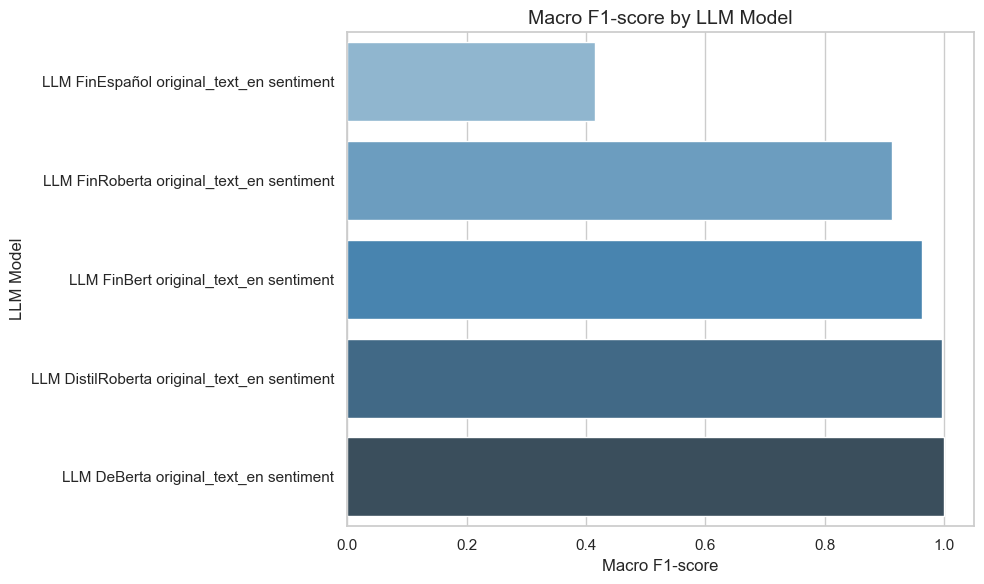

In [10]:
import seaborn as sns

# Convert and sort
f1_df = pd.DataFrame(list(f1_scores.items()), columns=['Model', 'Macro F1'])
f1_df = f1_df.sort_values(by='Macro F1', ascending=True)

# Plot setup
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

# Use 'hue' to assign palette and suppress legend
sns.barplot(
    data=f1_df,
    x='Macro F1',
    y='Model',
    hue='Model',
    palette='Blues_d',
    dodge=False,
    legend=False  # Avoid duplicate model legend
)

# Titles and labels
plt.title('Macro F1-score by LLM Model', fontsize=14)
plt.xlabel('Macro F1-score')
plt.ylabel('LLM Model')
plt.tight_layout()
plt.show()

---
---
## 🔲 VII. Matrices de Confusión

Para evaluar el desempeño de cada modelo de lenguaje (LLM) en la clasificación de sentimientos (negativo, neutral, positivo), se construyen y visualizan **matrices de confusión**:

- **Filas**: representan las verdaderas etiquetas de sentimiento.
- **Columnas**: representan las etiquetas predichas por el modelo.
- Cada celda indica el número de ejemplos que fueron clasificados en esa combinación de verdadero/predicho.

Estas matrices permiten identificar:
- **Aciertos**: se ubican en la diagonal principal (predicción correcta).
- **Errores**: valores fuera de la diagonal, muestran confusiones típicas entre clases.
- Se visualiza una matriz por cada modelo LLM probado.

La interpretación visual de las matrices de confusión ayuda a detectar patrones de error (por ejemplo, si un modelo tiende a confundir sentimientos negativos con neutros), facilitando la selección del modelo más robusto para la tarea de análisis de sentimiento.

---

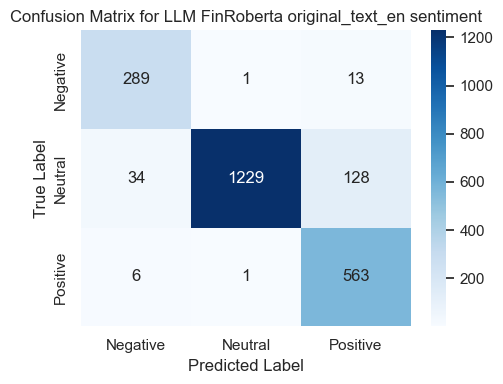

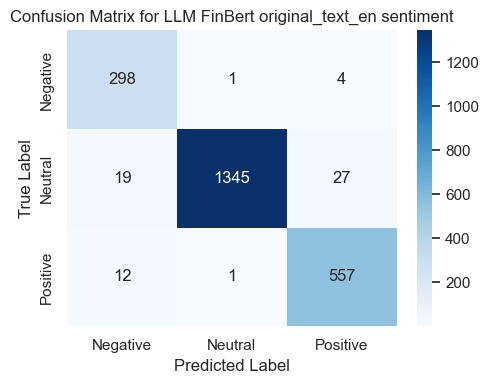

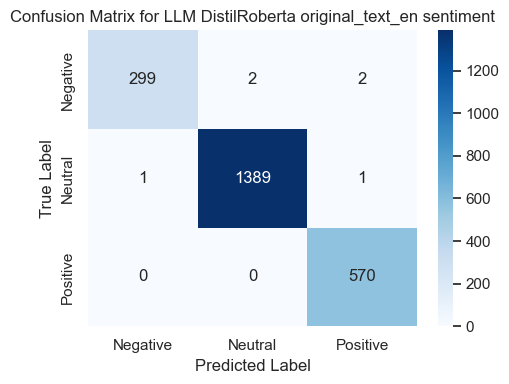

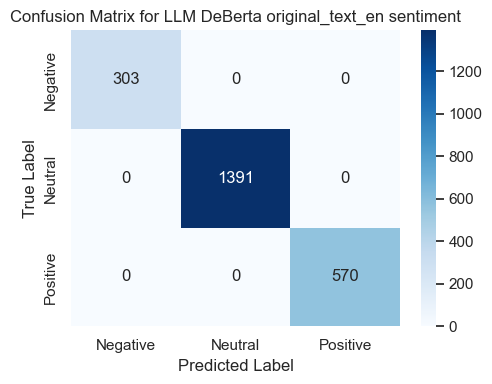

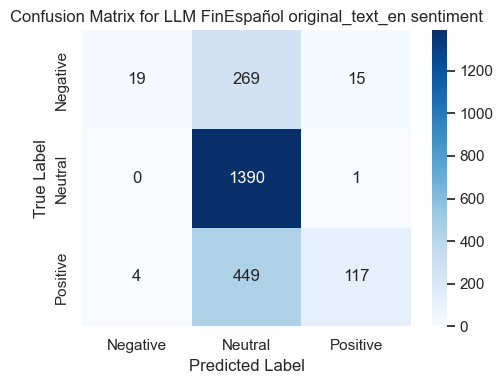

In [11]:
from sklearn.metrics import confusion_matrix

# Define class labels and their order
class_labels = [-1, 0, 1]  # negative, neutral, positive

# Plot one confusion matrix per model
for col in prediction_cols:
    y_true = df_original_EN['labeled_sentiment']
    y_pred = df_original_EN[col]

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)

    # Plot
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix for {col}', fontsize=12)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()